In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from identify import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist
from scipy.signal import detrend

In [2]:
# Load the Data's directory.
datadir = 'C:/Users/txu245/Desktop/06_01_07.zda'

# Load the Tool Packages.
dataLoader = DataLoader(datadir)
tools = Tools()
maps = Maps()
identify = Identify()

In [3]:
# Parameters setting up.
timeline = np.linspace(0, 299.5, 600)
stimulus = 100
basePt = 94
skipPt = 50
startPt = 94
numPt = 50

# Data Preprocessing.
Data = dataLoader.get_data()
Data = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data)
Rli = dataLoader.get_rli()
Data = tools.Rli_Division(Rli=Rli, Data=Data)
Data = tools.T_filter(Data=Data)
Data = tools.S_filter(sigma=1, Data=Data)
Data_ave = np.mean(Data, axis=0)

# SNR Map. (Without Normalization)
snr_map = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data)

# Rli Map.
rli_high = np.array(Rli['rli_high'])
rli_low = np.array(Rli['rli_low'])

rli = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli==0)
for coor in bad:
    rli[coor] = 0
rli = rli.reshape(80, 80)

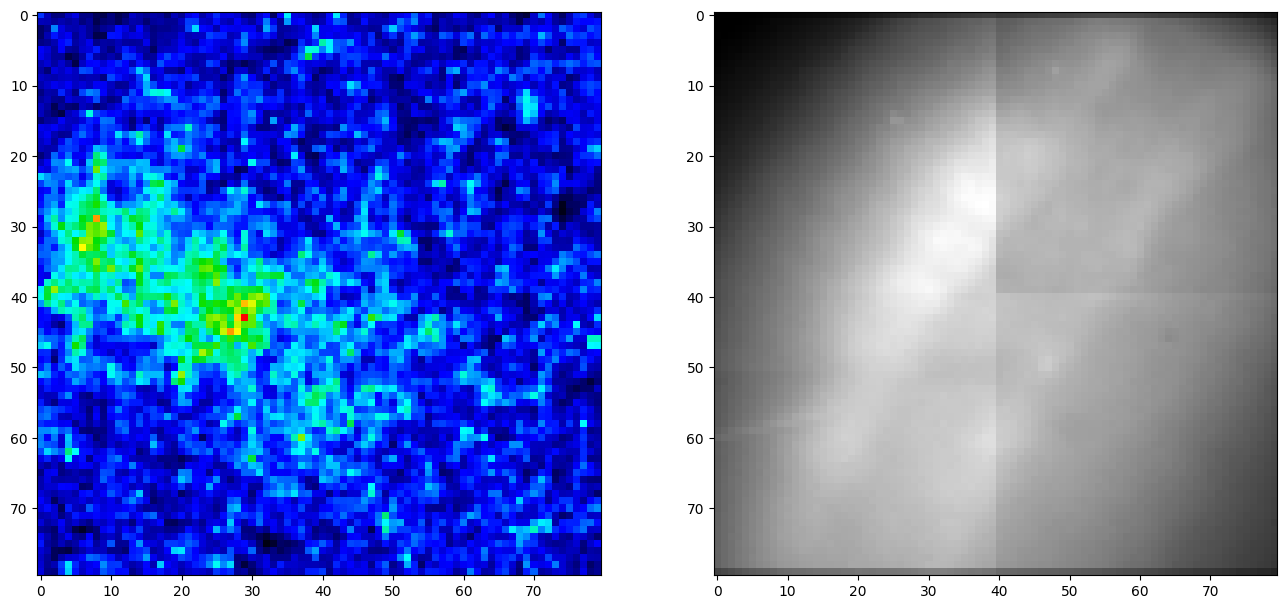

In [4]:
plt.subplots(1, 2, figsize=(16, 8))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(rli, cmap='gray')

plt.show()

In [5]:
# Single Cell Identification.
candidates = identify.candidates(Data_ave=Data_ave, cutoff=95, startPt=startPt, numPt=numPt)
candidates = identify.select_non_overlap(candidates=candidates, snr_map=snr_map)
candidates = sorted(candidates, key=lambda x: (x[0], x[1]))

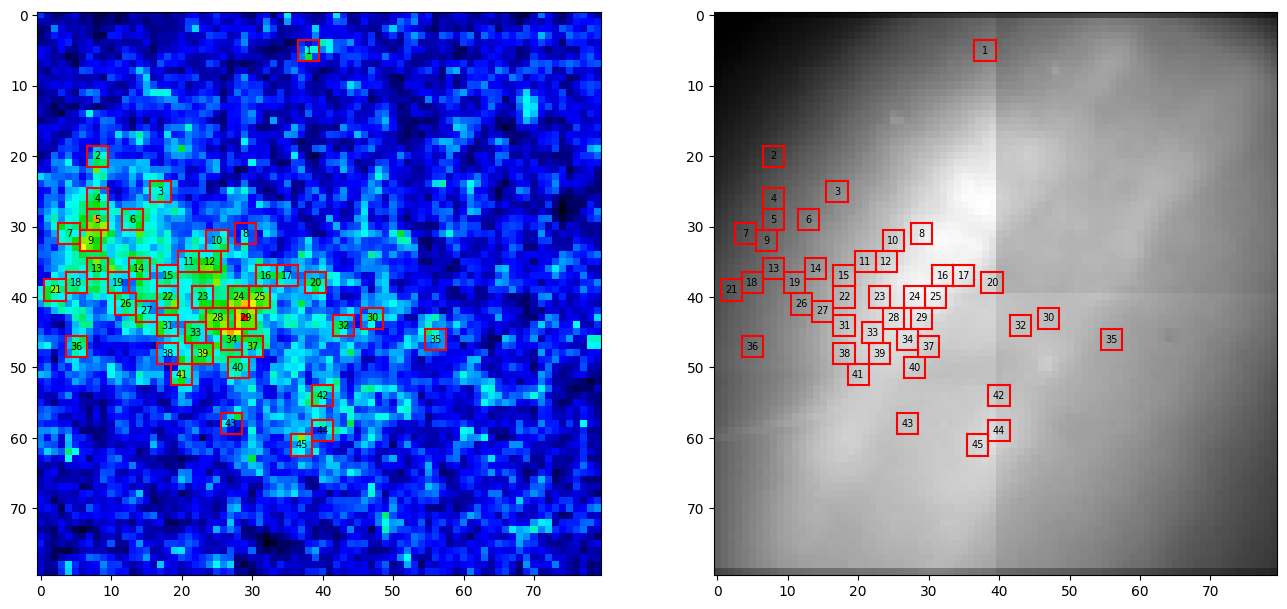

In [6]:
color = 'red'
linewidth = 1.5
index = np.array([[x[0], x[1]] for x in candidates])

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5
    '''
    if i == 24 or i == 92 or i==38:
        color = 'yellow'
        linewidth = 4.5
    '''
    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    
    color = 'red'
    linewidth = 1.5

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(rli, cmap='gray')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5
    '''
    if i == 24 or i == 92 or i==38:
        color = 'yellow'
        linewidth = 4.5
    '''
    # Draw square contour.
    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    
    color = 'red'
    linewidth = 1.5

plt.show()

In [7]:
num = len(index)
trial = Data.shape[0]
latency = np.zeros((num, trial))
trace = np.zeros((num, trial, len(timeline)))
judgement = np.ones(num)

for i in range(num):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates[i][3]:
            data_tem.append(Data[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        trace[i][j] = Trace
        latency[i][j] = maps.Max_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt, stimulus=stimulus)

Neuron 4 and Neuron 22 are active and correlated with a positive slope, and the P-Value is: 0.016977 , distance is: 103.22790320451152 um.
Neuron 4 and Neuron 35 are active and correlated with a positive slope, and the P-Value is: 0.002103 , distance is: 312.0 um.
Neuron 5 and Neuron 27 are active and correlated with a positive slope, and the P-Value is: 0.011517 , distance is: 88.58893836140041 um.
Neuron 5 and Neuron 30 are active and correlated with a positive slope, and the P-Value is: 0.044842 , distance is: 248.62019226120793 um.
Neuron 5 and Neuron 40 are active and correlated with a positive slope, and the P-Value is: 0.044464 , distance is: 174.0 um.
Neuron 6 and Neuron 9 are active and correlated with a positive slope, and the P-Value is: 0.031182 , distance is: 40.24922359499622 um.
Neuron 7 and Neuron 8 are active and correlated with a positive slope, and the P-Value is: 0.002239 , distance is: 150.0 um.
Neuron 7 and Neuron 36 are active and correlated with a positive slope

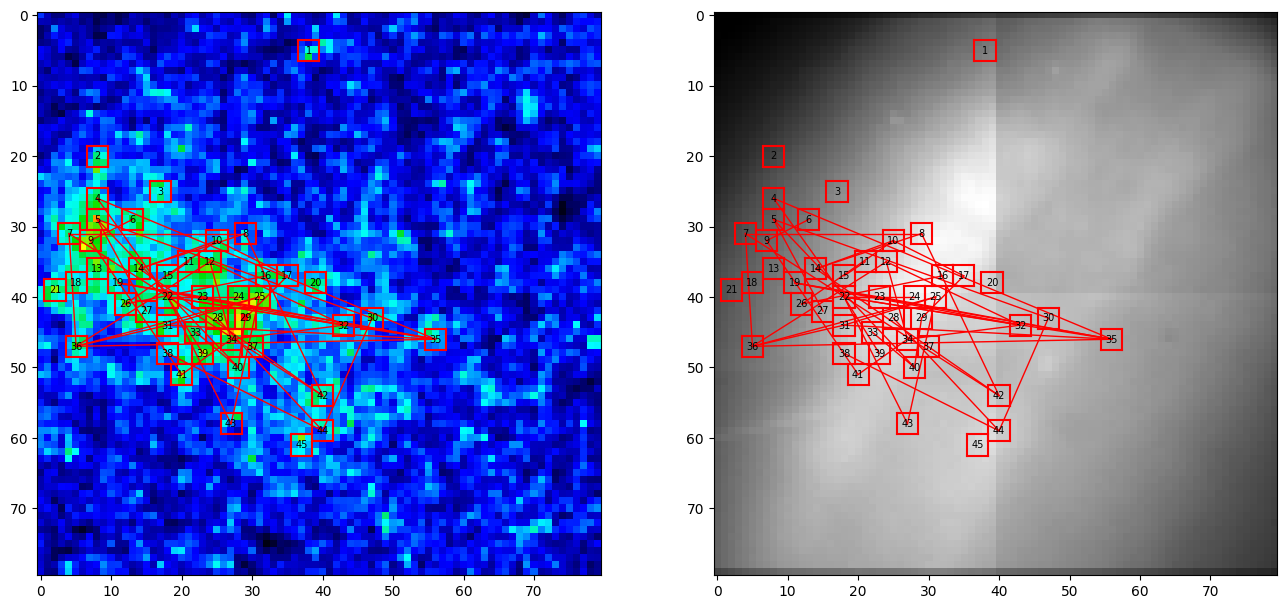

45 pairs are correlated.
Totally 990 pairs.


In [8]:
num = len(index)
trial = Data.shape[0]
connection = np.zeros(num, dtype=int)
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli, cmap='gray')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <= 0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are active and correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[j]
            connection[i] = connection[i] + 1
            connection[j] = connection[j] + 1
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')

In [ ]:
latency[17]

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(timeline, trace[17][17])
plt.axvline(50, color='red', linestyle='--')
plt.axvline(72, color='green')
plt.show()

In [ ]:
np.mean(connection)

In [ ]:
neuro_label = 36

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli, cmap='gray')


top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax1.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='black')

ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax2.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(num):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0 and judgement[i] == 1 and judgement[neuro_label-1] == 1:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are active and correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

            ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()
        

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(timeline, trace[1][3])
plt.xlim(0, timeline[-1])
plt.axvline(x=(stimulus/2), color='red', linestyle='--')
plt.axvline(x=(startPt/2), color='green')
plt.axvline(x=((startPt+numPt)/2), color='green')
plt.show()

In [ ]:
'''
with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_latency.dat', 'a') as f:
    for coor in latency:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_location.dat', 'a') as f:
    for coor in index:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_06_rli.dat', 'a') as f:
    for coor in rli:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')
'''